In [22]:
from pathlib import Path
import random

import gffutils
import numpy as np
import polars as pl
from safetensors.torch import load_file
from scipy.stats import entropy
import seaborn as sns
from statannotations.Annotator import Annotator
from tqdm import tqdm
from umap import UMAP

import torch

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
basepath = Path("/no_backup/rg/itrujnara/infer_chromosome/tensors")

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
size = 2**20
stride = size - 8192
chr_size = 46709983

In [5]:
db = gffutils.FeatureDB("/users/cn/itrujnara/genomes-project/infer_chromosome/compare_gff/gencode.v48.chr21.db")

In [6]:
def get_feature_ranges(gff_db, feature_type, gene_type=None, exclude_type=None, **kwargs):
    feature_ranges = []
    for feature in gff_db.features_of_type(feature_type):
        if gene_type is not None and gene_type not in feature["gene_type"]:
            continue
        if exclude_type is not None and exclude_type in feature["gene_type"]:
            continue
        feature_ranges.append((feature.start, feature.end))
    
    return feature_ranges

In [7]:
len(get_feature_ranges(db, "exon"))

13067

In [8]:
def get_intron_ranges(gff_db, gene_type=None, exclude_type=None, **kwargs):
    feature_ranges = []
    for feature in gff_db.create_introns():
        if gene_type is not None and gene_type not in feature["gene_type"]:
            continue
        if exclude_type is not None and exclude_type in feature["gene_type"]:
            continue
        feature_ranges.append((feature.start, feature.end))

    return feature_ranges

In [9]:
len(get_intron_ranges(db))

10778

In [10]:
def get_feature_embeddings(range_func, *args, **kwargs):
    ranges = range_func(*args, **kwargs)

    sample_size = kwargs.get("sample_size", 100)
    seed = kwargs.get("seed", 42)

    indices = np.concatenate([np.arange(start,end) for start,end in ranges])
    rng = np.random.default_rng()
    sample = np.sort(rng.choice(indices, size=sample_size))

    all_embeddings = []

    for start in tqdm(range(0,chr_size,stride)):
        offset = start + 8192
        end = start + size
        filename = f"ch38_chr21_{start}_{end}_embeddings.safetensors"

        try:
            chunk_embeddings = load_file(basepath / filename)["embeddings"]
        except FileNotFoundError:
            print(f"{filename} not found")
            continue

        for index in sample:
            if index >= end:
                break
            if index > offset:
                offset_idx = index - offset
                index_embeddings = chunk_embeddings[offset_idx,:].unsqueeze(0)
                all_embeddings.append(index_embeddings)

        del chunk_embeddings

    return torch.cat(all_embeddings, 0)

In [11]:
exon_emb = get_feature_embeddings(get_feature_ranges, db, "exon", sample_size=1000)

100%|██████████| 45/45 [00:00<00:00, 1958.49it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


In [12]:
exon_emb.shape

torch.Size([1000, 4096])

In [16]:
intron_emb = get_feature_embeddings(get_intron_ranges, db, sample_size=1000)

100%|██████████| 45/45 [00:00<00:00, 1938.58it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


In [14]:
intron_emb.shape

torch.Size([1000, 4096])

In [15]:
exon_exon_dist = torch.cdist(exon_emb.unsqueeze(0), exon_emb.unsqueeze(0)).flatten().to("cpu")

In [16]:
exon_exon_dist.mean()

tensor(7.6444)

Text(0.5, 0, 'Euclidean distance')

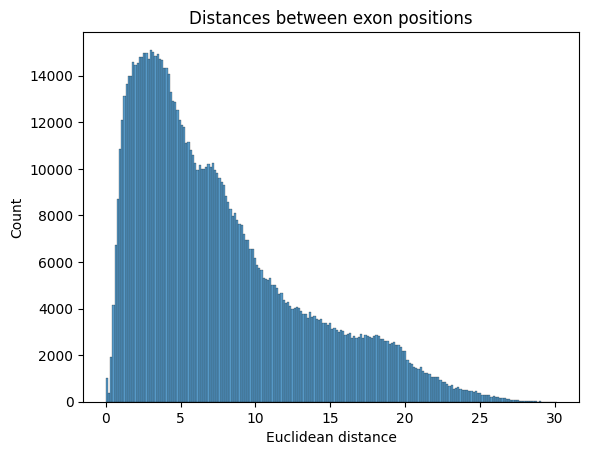

In [17]:
ax = sns.histplot(exon_exon_dist)

ax.set_title("Distances between exon positions")
ax.set_xlabel("Euclidean distance")

In [18]:
intron_intron_dist = torch.cdist(intron_emb.unsqueeze(0), intron_emb.unsqueeze(0)).flatten().to("cpu")

In [19]:
intron_intron_dist.mean()

tensor(5.0340)

Text(0.5, 0, 'Euclidean distance')

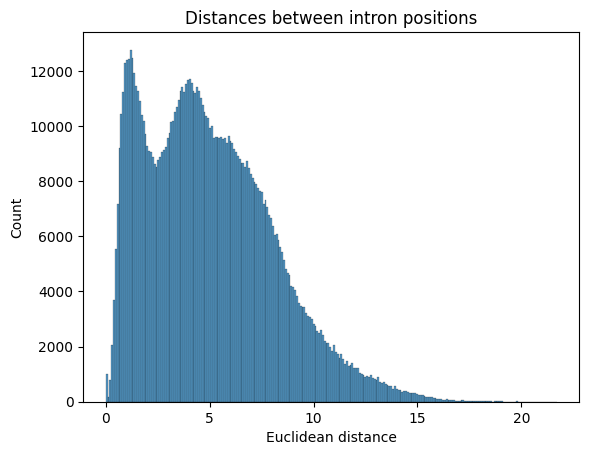

In [20]:
ax = sns.histplot(intron_intron_dist)

ax.set_title("Distances between intron positions")
ax.set_xlabel("Euclidean distance")

In [21]:
exon_intron_dist = torch.cdist(exon_emb.unsqueeze(0), intron_emb.unsqueeze(0)).flatten()

In [22]:
exon_intron_dist.mean()

tensor(6.4430)

Text(0.5, 0, 'Euclidean distance')

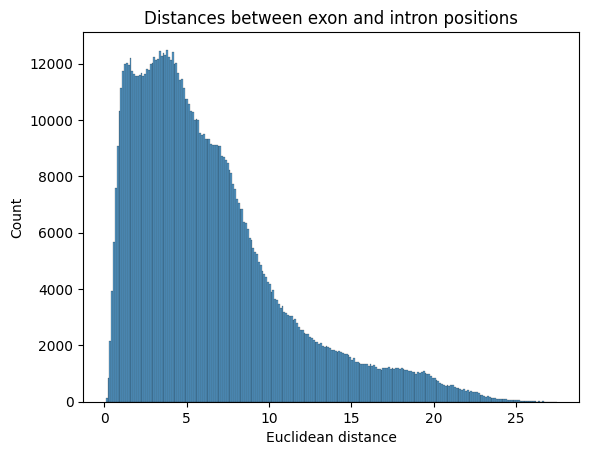

In [23]:
ax = sns.histplot(exon_intron_dist)

ax.set_title("Distances between exon and intron positions")
ax.set_xlabel("Euclidean distance")

## Protein coding exons

In [24]:
pc_exon_emb = get_feature_embeddings(get_feature_ranges, db, "exon", gene_type="protein_coding", sample_size=1000)

100%|██████████| 45/45 [00:00<00:00, 254.95it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


In [25]:
pc_exon_emb.shape

torch.Size([10000, 4096])

In [26]:
pc_exon_exon_dist = torch.cdist(pc_exon_emb.unsqueeze(0), pc_exon_emb.unsqueeze(0)).flatten()

In [27]:
pc_exon_exon_dist.mean()

tensor(10.2377)

In [28]:
pc_exon_intron_dist = torch.cdist(pc_exon_emb.unsqueeze(0), intron_emb.unsqueeze(0))

In [29]:
pc_exon_intron_dist.mean()

tensor(7.9937)

## CDS

In [11]:
cds_emb = get_feature_embeddings(get_feature_ranges, db, "CDS", gene_type="protein_coding", sample_size=1000)

  0%|          | 0/45 [00:00<?, ?it/s]

ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


100%|██████████| 45/45 [00:01<00:00, 30.66it/s]


In [13]:
cds_cds_dist = torch.cdist(cds_emb.unsqueeze(0), cds_emb.unsqueeze(0))

In [15]:
cds_cds_dist.mean()

tensor(13.5849)

In [17]:
cds_intron_dist = torch.cdist(cds_emb.unsqueeze(0), intron_emb.unsqueeze(0))

In [19]:
cds_intron_dist.mean()

tensor(10.5353)

In [20]:
df_cds = pl.DataFrame({"embedding": cds_emb.numpy(), "label": ["CDS"] * cds_emb.shape[0]})

In [23]:
df_intron = pl.DataFrame({"embedding": intron_emb.numpy(), "label": ["Intron"] * intron_emb.shape[0]})

In [29]:
df_cds_intron = df_cds.vstack(df_intron).with_columns(pl.col("embedding").arr.to_struct()).unnest("embedding")

In [30]:
df_cds_intron

field_0,field_1,field_2,field_3,field_4,field_5,field_6,field_7,field_8,field_9,field_10,field_11,field_12,field_13,field_14,field_15,field_16,field_17,field_18,field_19,field_20,field_21,field_22,field_23,field_24,field_25,field_26,field_27,field_28,field_29,field_30,field_31,field_32,field_33,field_34,field_35,field_36,…,field_4060,field_4061,field_4062,field_4063,field_4064,field_4065,field_4066,field_4067,field_4068,field_4069,field_4070,field_4071,field_4072,field_4073,field_4074,field_4075,field_4076,field_4077,field_4078,field_4079,field_4080,field_4081,field_4082,field_4083,field_4084,field_4085,field_4086,field_4087,field_4088,field_4089,field_4090,field_4091,field_4092,field_4093,field_4094,field_4095,label
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str
0.014587,-0.019043,0.030151,0.004669,0.044678,0.008301,-0.016724,0.034668,0.005249,-0.089355,0.022095,-0.015198,0.059814,-0.177734,-0.492188,0.007141,-0.010803,0.001854,-0.009949,-0.009949,0.018311,-0.015991,0.223633,-0.003967,0.008606,-0.015747,-0.027954,-0.15625,0.054932,-0.013916,0.039551,0.020386,0.003433,0.059814,0.031494,-0.020508,0.021729,…,-0.005463,-0.009216,-0.017578,0.003036,-0.016235,-0.00531,0.046875,-0.083984,-0.003632,-0.047119,-0.071777,-0.029785,0.017212,-0.012695,0.023071,0.087891,0.12793,0.020752,-0.018433,-0.012085,-0.016479,0.03418,0.025024,-0.029419,0.4375,0.021729,-0.026245,-0.039551,0.024658,-0.023438,-0.016113,0.021973,0.066406,0.007294,0.010071,-0.009827,"""CDS"""
0.015259,-0.018066,0.028564,0.00531,0.046143,0.008484,-0.016968,0.035156,0.005371,-0.094727,0.021973,-0.015442,0.054199,-0.133789,-0.492188,0.007446,-0.011414,-0.003159,-0.010071,-0.010193,0.018799,-0.016724,0.251953,-0.004089,0.12207,-0.015991,-0.02832,-0.15625,0.053223,-0.013977,0.023193,0.01709,0.003723,0.051758,0.032227,-0.021118,0.022217,…,-0.003601,-0.009399,-0.018677,0.003067,-0.01709,-0.005493,0.044434,-0.092773,-0.003662,-0.048584,-0.073242,-0.033936,0.017456,-0.012573,0.024902,0.090332,0.151367,0.029907,-0.021118,-0.012085,-0.016846,0.033936,0.021362,-0.029907,0.410156,0.021973,-0.026855,-0.037109,0.026123,-0.024048,-0.0177,0.022217,0.068359,0.007416,0.010498,-0.010254,"""CDS"""
0.014465,-0.019287,0.031128,0.004333,0.04126,0.011108,-0.016602,0.034668,0.005188,-0.090332,0.021606,-0.015015,0.032471,0.124512,-0.5,0.00708,-0.010925,-0.002029,-0.009827,-0.009888,0.018311,-0.015991,0.238281,-0.003937,0.142578,-0.015625,-0.02771,-0.174805,0.0546875,-0.013794,0.021606,0.019775,0.003433,0.047119,0.03125,-0.02063,0.02124,…,-0.00473,-0.009155,-0.017456,0.003021,-0.016357,-0.005249,0.046143,-0.095703,-0.00351,-0.046875,-0.071289,-0.031128,0.017334,-0.012329,0.022827,0.081055,0.125,0.011597,-0.022461,-0.011719,-0.016235,0.033203,0.02124,-0.029175,0.416016,0.021606,-0.026001,-0.038574,0.02356,-0.023438,-0.015747,0.021851,0.066895,0.007233,0.01001,-0.009827,"""CDS"""
0.01416,-0.017212,0.020386,0.002747,0.033447,0.021729,-0.015747,0.032227,0.004761,-0.089355,0.02063,-0.014343,0.007568,0.010986,-0.404297,0.006927,-0.010803,-0.000387,-0.009155,-0.009338,0.017212,-0.015747,0.253906,-0.003799,0.423828,-0.014832,-0.026245,-0.162109,0.051758,-0.012878,0.001022,0.011597,0.004059,0.006622,0.029663,-0.019775,0.019775,…,-0.001015,-0.008728,-0.017822,0.002823,-0.015991,-0.005066,0.040283,-0.077148,-0.003387,-0.046143,-0.067871,-0.037354,0.016235,-0.011475,0.024658,0.067383,0.154297,0.054443,-0.027832,-0.012634,-0.015564,0.03125,0.01123,-0.02832,0.402344,0.02002,-0.025757,-0.030396,0.02124,-0.022095,-0.015991,0.020264,0.064453,0.006775,0.01001,-0.009521,"""CDS"""
0.013611,-0.013123,0.014709,0.003189,0.021729,0.027466,-0.015137,0.031982,0.004791,-0.094727,0.020386,-0.014038,0.021729,-0.539062,-0.359375,0.00705,-0.010925,0.015869,-0.009033,-0.009216,0.0170

In [26]:
reducer = UMAP()

In [33]:
umap_embedding = reducer.fit_transform(df_cds_intron.select(pl.exclude("label")))

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## Boxplot

In [30]:
df_exon_exon = pl.DataFrame({"value": exon_exon_dist, "label": ["Exon vs Exon"] * exon_exon_dist.shape[0]})

In [31]:
df_intron_intron = pl.DataFrame({"value": intron_intron_dist, "label": ["Intron vs Intron"] * intron_intron_dist.shape[0]})

In [32]:
df_exon_intron = pl.DataFrame({"value": exon_intron_dist, "label": ["Exon vs Intron"] * exon_intron_dist.shape[0]})

In [33]:
df_all = df_exon_exon.vstack(df_intron_intron).vstack(df_exon_intron)

Text(0, 0.5, 'Euclidean distance')

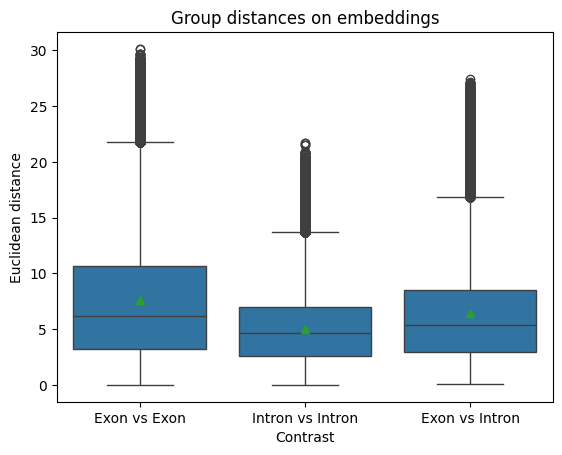

In [35]:
ax = sns.boxplot(df_all, x="label", y="value", showmeans=True)

ax.set_title("Group distances on embeddings")
ax.set_xlabel("Contrast")
ax.set_ylabel("Euclidean distance")